In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.shape
df.info()
df.isnull().sum()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


I ran these commands to load and understand/inspect the data.
From the output i can see the following:
 1. The dates are in str from not datetime.
 2. The no. of states are missing (there are only 49,ill be inspecting it in next cell).
 3. The postal column is missing 11 values(only 9789/9800 are non-null).
 4. Sales might contain some outliers.
 5. There is a miss-match in product id and names(1861vs1849[the name is missing 12 unique values])

In [5]:
df['State'].unique()

<StringArray>
[            'Kentucky',           'California',              'Florida',
       'North Carolina',           'Washington',                'Texas',
            'Wisconsin',                 'Utah',             'Nebraska',
         'Pennsylvania',             'Illinois',            'Minnesota',
             'Michigan',             'Delaware',              'Indiana',
             'New York',              'Arizona',             'Virginia',
            'Tennessee',              'Alabama',       'South Carolina',
               'Oregon',             'Colorado',                 'Iowa',
                 'Ohio',             'Missouri',             'Oklahoma',
           'New Mexico',            'Louisiana',          'Connecticut',
           'New Jersey',        'Massachusetts',              'Georgia',
               'Nevada',         'Rhode Island',          'Mississippi',
             'Arkansas',              'Montana',        'New Hampshire',
             'Maryland', 'District of

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-Category   9800 non-null   s

In [7]:
df[df['Postal Code'].isnull()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2234,2235,CA-2018-104066,2018-12-05,2018-12-10,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03
5274,5275,CA-2016-162887,2016-11-07,2016-11-09,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
8798,8799,US-2017-150140,2017-04-06,2017-04-10,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
9146,9147,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
9147,9148,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
9148,9149,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
9386,9387,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92
9387,9388,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28
9388,9389,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
9389,9390,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04


In [8]:
df['Postal Code'] = df['Postal Code'].fillna(5401) #Burlington, Vermont, USA postal code is 5401.
df[df['Postal Code'].isnull()]['City'].unique() #return nothing since we have filled the null values with respective postal codes.

<StringArray>
[]
Length: 0, dtype: str

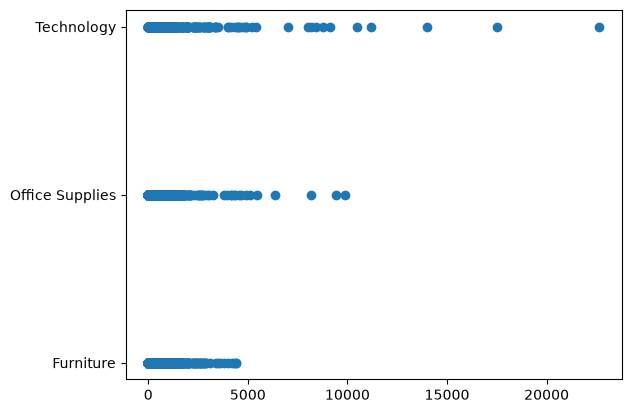

In [9]:
df.head()
plt.scatter(df['Sales'], df['Category'])
plt.show()

In [10]:
df.sort_values(by ='Sales', ascending=False).head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2697,2698,CA-2015-145317,2015-03-18,2015-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,Florida,32216.0,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480
6826,6827,CA-2017-118689,2017-10-02,2017-10-09,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,Indiana,47905.0,Central,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950
8153,8154,CA-2018-140151,2018-03-23,2018-03-25,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,Washington,98115.0,West,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960
2623,2624,CA-2018-127180,2018-10-22,2018-10-24,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,New York,10024.0,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968
4190,4191,CA-2018-166709,2018-11-17,2018-11-22,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,Delaware,19711.0,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970
9039,9040,CA-2017-117121,2017-12-17,2017-12-21,Standard Class,AB-10105,Adrian Barton,Consumer,United States,Detroit,Michigan,48205.0,Central,OFF-BI-10000545,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.740
4098,4099,CA-2015-116904,2015-09-23,2015-09-28,Standard Class,SC-20095,Sanjit Chand,Consumer,United States,Minneapolis,Minnesota,55407.0,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,9449.950
4277,4278,US-2017-107440,2017-04-16,2017-04-20,Standard Class,BS-11365,Bill Shonely,Corporate,United States,Lakewood,New Jersey,8701.0,East,TEC-MA-10001047,Technology,Machines,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930
8488,8489,CA-2017-158841,2017-02-02,2017-02-04,Second Class,SE-20110,Sanjit Engle,Consumer,United States,Arlington,Virginia,22204.0,South,TEC-MA-10001127,Technology,Machines,HP Designjet T520 Inkjet Large Format Printer ...,8749.950
6425,6426,CA-2017-143714,2017-05-23,2017-05-27,Standard Class,CC-12370,Christopher Conant,Consumer,United States,Philadelphia,Pennsylvania,19120.0,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,8399.976


In [11]:
df.groupby('Product Name')['Product ID'].nunique().sort_values(ascending=False).head(10)

Product Name
Staples                        10
Staple envelope                 9
Easy-staple paper               8
Staples in misc. colors         7
Staple holder                   3
Staple remover                  3
Avery Non-Stick Binders         2
Eldon Wave Desk Accessories     2
KI Adjustable-Height Table      2
Okidata C610n Printer           2
Name: Product ID, dtype: int64

 1. The postal column is missing 11 values(only 9789/9800 are non-null). [ &check; FIXED]
 2. Sales might contain some outliers.[ &check; FIXED]
 3. There is a miss-match in product id and names(1861vs1849[the name is missing 12 unique values]) [ &check; FIXED]


NOW ILL BE ANSWERING SOME QUES BASED ON THE DATABASE:
 1. Does shipping time vary meaningfully by Region or Ship Mode — and are any regions consistently getting slower shipping?
 2. Which regions/states drive the most total sales — and are any underperforming relative to how many orders they have?
 3. Is there a seasonal pattern in sales over time (by month or quarter)?
 4. Which product categories/sub-categories sell the most, and does that differ by customer segment? 

In [12]:
#Q1. 
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.total_seconds() / 86400
df['Shipping Days'] = df['Shipping Days'].astype(int)
df['Shipping Days'].head()
print(pd.__version__)
#I had to check the version of pandas because the previous method of calculating shipping days was not working
# I found that the version of pandas I was using doesn't supprt .dt.days, 
# so I had to use .dt.total_seconds() instead and divide by 86400 to get the number of days.

3.0.3


In [13]:
df['Shipping Days'].describe()

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

In [14]:
df.groupby('Region')["Shipping Days"].mean().sort_values(ascending=False)

Region
Central    4.065876
South      3.961202
West       3.930255
East       3.910233
Name: Shipping Days, dtype: float64

In [15]:
df.groupby('Ship Mode')["Shipping Days"].mean().sort_values(ascending=False)

Ship Mode
Standard Class    5.008363
Second Class      3.249211
First Class       2.179214
Same Day          0.044610
Name: Shipping Days, dtype: float64

In [16]:
df.groupby('Category')["Shipping Days"].mean().sort_values(ascending=False)

Category
Office Supplies    3.984600
Furniture          3.926853
Technology         3.923883
Name: Shipping Days, dtype: float64

C:\Users\aarsh\AppData\Local\Temp\ipykernel_20120\164284373.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= Ship_Summary.index, y= Ship_Summary.values, order= ['Same Day', 'First Class', 'Second Class', 'Standard Class' ],palette='RdYlGn_r')


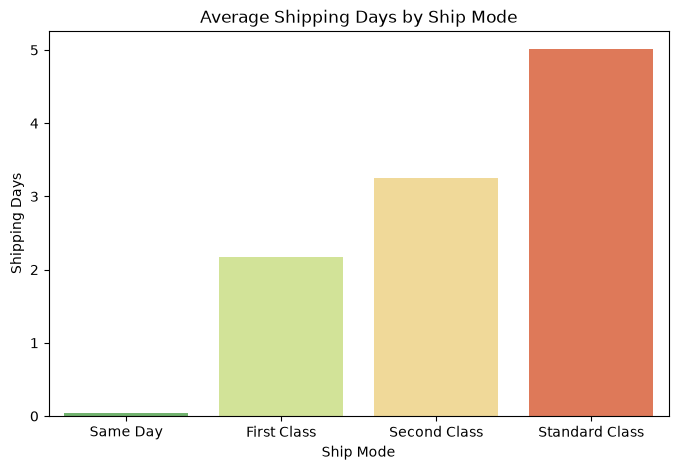

In [17]:
Ship_Summary = df.groupby('Ship Mode')["Shipping Days"].mean()
plt.figure(figsize=(8,5))
sns.barplot(x= Ship_Summary.index, y= Ship_Summary.values, order= ['Same Day', 'First Class', 'Second Class', 'Standard Class' ],palette='RdYlGn_r')
plt.title('Average Shipping Days by Ship Mode')
plt.xlabel('Ship Mode') 
plt.ylabel('Shipping Days')
plt.show()

In [18]:
# Q2.
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

In [19]:
df.groupby('Region')['Sales'].agg(['sum', 'count', 'mean']).sort_values('sum', ascending=False)

,sum,count,mean
Region,,,
West,710219.6845,3140,226.184613
East,669518.7260,2785,240.401697
Central,492646.9132,2277,216.357889
South,389151.4590,1598,243.524067


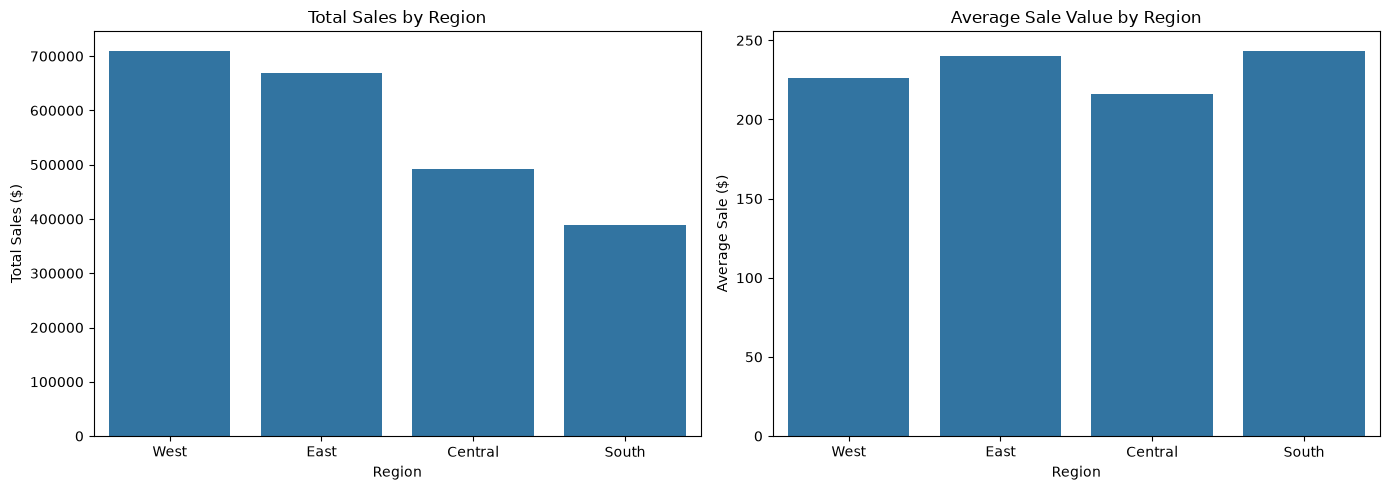

In [24]:
region_summary = df.groupby('Region')['Sales'].agg(['sum', 'count', 'mean']).sort_values('sum', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.barplot(x=region_summary.index, y=region_summary['sum'], ax=axes[0])
axes[0].set_title('Total Sales by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Total Sales ($)')

sns.barplot(x=region_summary.index, y=region_summary['mean'], ax=axes[1])
axes[1].set_title('Average Sale Value by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Average Sale ($)')

plt.tight_layout()
plt.show()

In [27]:
# Q3.
df['Order Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Order Month')['Sales'].sum()
monthly_sales

Order Month
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     75249.3995
2016-12     74543.6012
2017-01     18542.4910
2017-02     22978.8150
2017-03     51165.0590
2017-04     38679.7670
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59583.0330
2017-11     79066.4958
2017-12     95739.1210
2018-01     43476.4740
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07     44825.1040

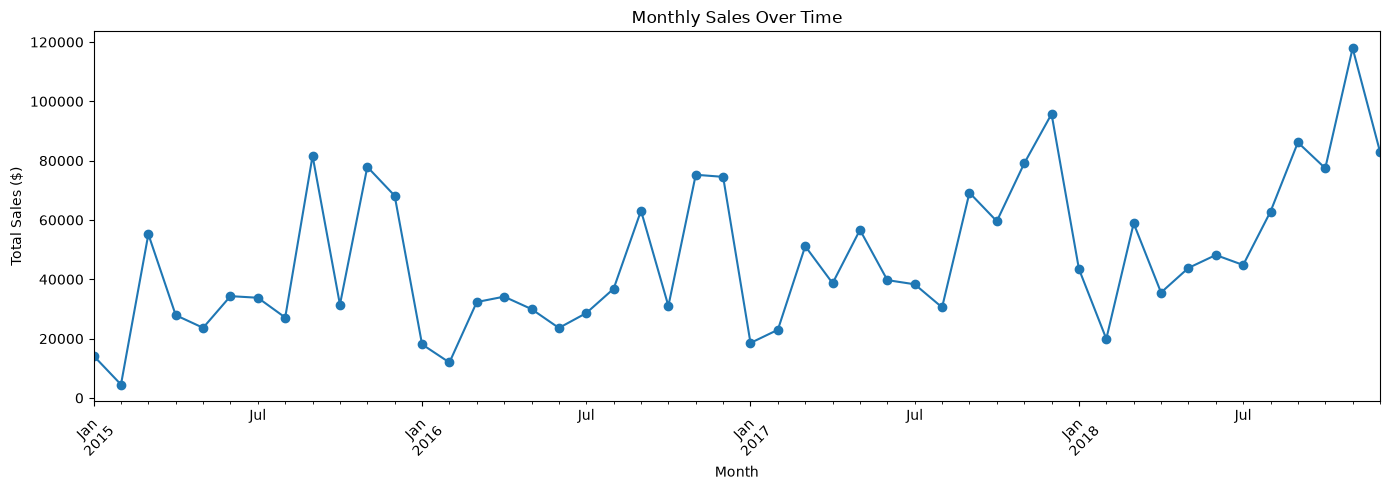

In [28]:
plt.figure(figsize=(14,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sales show a consistent seasonal pattern, dipping each January-February and peaking each November-December, layered on top of clear year-over-year growth.

The November 2018 peak (~$118K) is roughly 8x higher than the lowest point in early 2015 (~$5K). 

This is a strong, quotable insight,precise, backed by the chart, tells a real business story (seasonality + growth).

In [29]:
# Q4.
category_segment = df.groupby(['Category', 'Segment'])['Sales'].sum().unstack()
category_segment

Segment,Consumer,Corporate,Home Office
Category,,,
Furniture,387696.258,220321.7018,120640.6159
Office Supplies,359352.608,224130.5360,121939.1900
Technology,401011.665,244041.8370,182402.3710


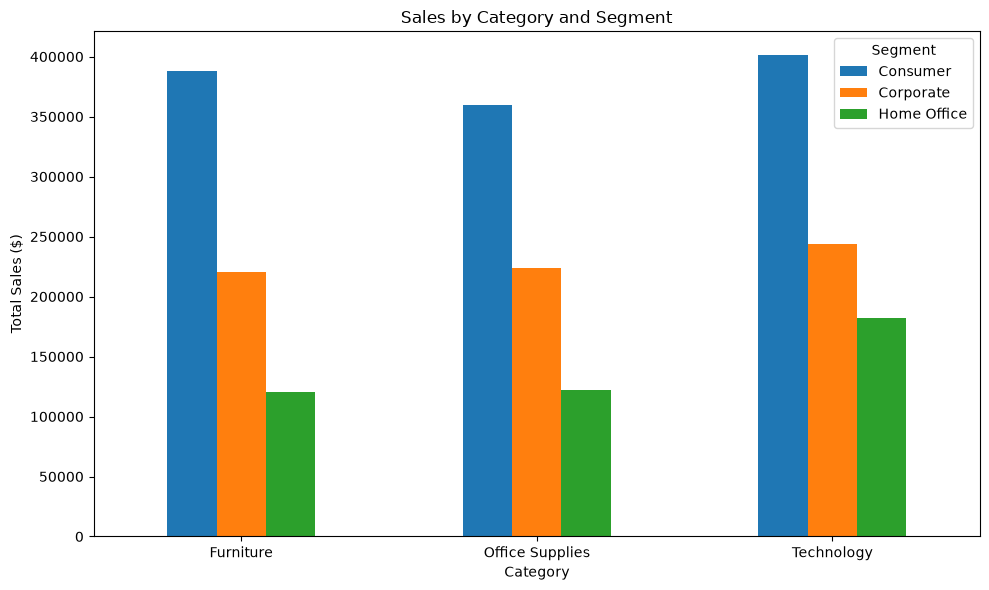

In [31]:
category_segment.plot(kind='bar', figsize=(10,6))
plt.title('Sales by Category and Segment')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.legend(title='Segment')
plt.tight_layout()
plt.show()